In [1]:
symbol = 'TQQQ'

import yfinance
hist = yfinance.download(tickers=symbol,period="7d",interval="1m")

[*********************100%***********************]  1 of 1 completed


In [2]:
# change column name to lower case and without space.
# option 1
new_col_list = []
for i in hist.columns:
    new_col_list.append(i.lower().replace(" ", ""))
hist.columns = new_col_list

In [3]:
# option 2 
# dataframe.columns.values == array
# dataframe.columns == index
# pandas does not want pd.Indexs to be mutable
for i,j in enumerate(hist.columns):
    hist.columns.values[i] = j.lower().replace(" ", "")


In [4]:
hist

,open,high,low,close,adjclose,volume
Datetime,,,,,,
2023-03-15 09:30:00-04:00,22.170000,22.338699,22.100000,22.246799,22.246799,23455801
2023-03-15 09:31:00-04:00,22.240000,22.299999,22.180000,22.270000,22.270000,1040095
2023-03-15 09:32:00-04:00,22.270000,22.330000,22.180000,22.235001,22.235001,1209502
2023-03-15 09:33:00-04:00,22.240000,22.360001,22.170000,22.349899,22.349899,1346112
2023-03-15 09:34:00-04:00,22.345900,22.480000,22.309999,22.390100,22.390100,1526564
...,...,...,...,...,...,...
2023-03-23 15:55:00-04:00,25.690001,25.740000,25.590000,25.649900,25.649900,780910
2023-03-23 15:56:00-04:00,25.650000,25.722900,25.629999,25.688801,25.688801,647462
2023-03-23 15:57:00-04:00,25.690001,25.725599,25.660000,25.719999,25.719999,478159


In [5]:
(hist==0).sum().sum()

0

In [6]:
# in case zeros value in dataset, change zeros to ones for a better calculation
hist.replace(0,1,inplace=True)

In [7]:
hist['close'].rolling(20).mean()

Datetime
2023-03-15 09:30:00-04:00          NaN
2023-03-15 09:31:00-04:00          NaN
2023-03-15 09:32:00-04:00          NaN
2023-03-15 09:33:00-04:00          NaN
2023-03-15 09:34:00-04:00          NaN
                               ...    
2023-03-23 15:55:00-04:00    25.551245
2023-03-23 15:56:00-04:00    25.565435
2023-03-23 15:57:00-04:00    25.580685
2023-03-23 15:58:00-04:00    25.595685
2023-03-23 15:59:00-04:00    25.604685
Name: close, Length: 2726, dtype: float64

In [8]:
import numpy as np
import pandas as pd
import pandas_datareader as pdr
import matplotlib.pyplot as plt

def get_bollinger_bands(data, rate=20):
    sma = data['close'].rolling(rate).mean()
    std = data['close'].rolling(rate).std()
    bollinger_up = pd.Series(sma + std * 2, name = 'bollinger_up_' + str(rate)) # Calculate top band
    bollinger_down = pd.Series(sma - std * 2, name ='bollinger_down_' + str(rate)) # Calculate bottom band
    data = data.join([bollinger_up,bollinger_down])
    return data

# symbol = 'AAPL'
# df = pdr.DataReader(symbol, 'yahoo', '2014-07-01', '2015-07-01')
# df.index = np.arange(df.shape[0])




In [9]:
def SMA(data, ndays=20): 
    SMA = pd.Series(data['close'].rolling(ndays).mean(), name = 'SMA_'+ str(ndays)) 
    data = data.join(SMA) 
    return data

In [10]:
def EWMA(data, ndays=20): 
    EMA = pd.Series(data['close'].ewm(span = ndays, min_periods = ndays - 1).mean(), 
                 name = 'EWMA_' + str(ndays)) 
    data = data.join(EMA) 
    return data

In [11]:
def rsi(data, periods = 20):
    
    close_delta = data['close'].diff()

    # Make two series: one for lower closes and one for higher closes
    up = close_delta.clip(lower=0)
    down = -1 * close_delta.clip(upper=0)
    
    ma_up = up.ewm(com = periods - 1, adjust=True, min_periods = periods).mean()
    ma_down = down.ewm(com = periods - 1, adjust=True, min_periods = periods).mean()

    rsi = ma_up / ma_down
    rsi = 100 - (100/(1 + rsi))
    RSI = pd.Series(rsi, name='RSI_' + str(periods))
    data = data.join(RSI)
    return data

In [12]:
def gain(x):
    return ((x > 0) * x).sum()


def loss(x):
    return ((x < 0) * x).sum()


# Calculate money flow index
def mfi(data, n=20):
    high = data['high']
    low = data['low']
    close = data['close']
    volume = data['volume']
    typical_price = (high + low + close)/3
    money_flow = typical_price * volume
    mf_sign = np.where(typical_price > typical_price.shift(1), 1, -1)
    signed_mf = money_flow * mf_sign
    mf_avg_gain = signed_mf.rolling(n).apply(gain, raw=True)
    mf_avg_loss = signed_mf.rolling(n).apply(loss, raw=True)
    mfi = (100 - (100 / (1 + (mf_avg_gain / abs(mf_avg_loss)))))
    MFI = pd.Series(mfi, name='MFI_' + str(n))
    data = data.join(MFI)
    return data

In [13]:
def percent_change(data, level = 'close'):
    PER = pd.Series((data[level] - data[level].shift(1))/data[level].shift(1)*100, name = 'PER_'+level)
    data = data.join(PER)
    return data
    

In [14]:
hist = mfi(hist,14)

In [15]:
hist

,open,high,low,close,adjclose,volume,MFI_14
Datetime,,,,,,,
2023-03-15 09:30:00-04:00,22.170000,22.338699,22.100000,22.246799,22.246799,23455801,NaN
2023-03-15 09:31:00-04:00,22.240000,22.299999,22.180000,22.270000,22.270000,1040095,NaN
2023-03-15 09:32:00-04:00,22.270000,22.330000,22.180000,22.235001,22.235001,1209502,NaN
2023-03-15 09:33:00-04:00,22.240000,22.360001,22.170000,22.349899,22.349899,1346112,NaN
2023-03-15 09:34:00-04:00,22.345900,22.480000,22.309999,22.390100,22.390100,1526564,NaN
...,...,...,...,...,...,...,...
2023-03-23 15:55:00-04:00,25.690001,25.740000,25.590000,25.649900,25.649900,780910,57.233864
2023-03-23 15:56:00-04:00,25.650000,25.722900,25.629999,25.688801,25.688801,647462,58.002279
2023-03-23 15:57:00-04:00,25.690001,25.725599,25.660000,25.719999,25.719999,478159,57.018960


In [16]:
hist = rsi(hist, 14)

In [17]:
hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14
Datetime,,,,,,,,
2023-03-15 09:30:00-04:00,22.170000,22.338699,22.100000,22.246799,22.246799,23455801,NaN,NaN
2023-03-15 09:31:00-04:00,22.240000,22.299999,22.180000,22.270000,22.270000,1040095,NaN,NaN
2023-03-15 09:32:00-04:00,22.270000,22.330000,22.180000,22.235001,22.235001,1209502,NaN,NaN
2023-03-15 09:33:00-04:00,22.240000,22.360001,22.170000,22.349899,22.349899,1346112,NaN,NaN
2023-03-15 09:34:00-04:00,22.345900,22.480000,22.309999,22.390100,22.390100,1526564,NaN,NaN
...,...,...,...,...,...,...,...,...
2023-03-23 15:55:00-04:00,25.690001,25.740000,25.590000,25.649900,25.649900,780910,57.233864,57.529196
2023-03-23 15:56:00-04:00,25.650000,25.722900,25.629999,25.688801,25.688801,647462,58.002279,59.371267
2023-03-23 15:57:00-04:00,25.690001,25.725599,25.660000,25.719999,25.719999,478159,57.018960,60.838307


In [18]:
hist = get_bollinger_bands(hist, 14)

In [19]:
hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14
Datetime,,,,,,,,,,
2023-03-15 09:30:00-04:00,22.170000,22.338699,22.100000,22.246799,22.246799,23455801,NaN,NaN,NaN,NaN
2023-03-15 09:31:00-04:00,22.240000,22.299999,22.180000,22.270000,22.270000,1040095,NaN,NaN,NaN,NaN
2023-03-15 09:32:00-04:00,22.270000,22.330000,22.180000,22.235001,22.235001,1209502,NaN,NaN,NaN,NaN
2023-03-15 09:33:00-04:00,22.240000,22.360001,22.170000,22.349899,22.349899,1346112,NaN,NaN,NaN,NaN
2023-03-15 09:34:00-04:00,22.345900,22.480000,22.309999,22.390100,22.390100,1526564,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2023-03-23 15:55:00-04:00,25.690001,25.740000,25.590000,25.649900,25.649900,780910,57.233864,57.529196,25.852419,25.398652
2023-03-23 15:56:00-04:00,25.650000,25.722900,25.629999,25.688801,25.688801,647462,58.002279,59.371267,25.849546,25.434211
2023-03-23 15:57:00-04:00,25.690001,25.725599,25.660000,25.719999,25.719999,478159,57.018960,60.838307,25.849366,25.467690


In [20]:
hist = percent_change(hist, 'close')

In [21]:
hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close
Datetime,,,,,,,,,,,
2023-03-15 09:30:00-04:00,22.170000,22.338699,22.100000,22.246799,22.246799,23455801,NaN,NaN,NaN,NaN,NaN
2023-03-15 09:31:00-04:00,22.240000,22.299999,22.180000,22.270000,22.270000,1040095,NaN,NaN,NaN,NaN,0.104289
2023-03-15 09:32:00-04:00,22.270000,22.330000,22.180000,22.235001,22.235001,1209502,NaN,NaN,NaN,NaN,-0.157161
2023-03-15 09:33:00-04:00,22.240000,22.360001,22.170000,22.349899,22.349899,1346112,NaN,NaN,NaN,NaN,0.516747
2023-03-15 09:34:00-04:00,22.345900,22.480000,22.309999,22.390100,22.390100,1526564,NaN,NaN,NaN,NaN,0.179872
...,...,...,...,...,...,...,...,...,...,...,...
2023-03-23 15:55:00-04:00,25.690001,25.740000,25.590000,25.649900,25.649900,780910,57.233864,57.529196,25.852419,25.398652,-0.175518
2023-03-23 15:56:00-04:00,25.650000,25.722900,25.629999,25.688801,25.688801,647462,58.002279,59.371267,25.849546,25.434211,0.151659
2023-03-23 15:57:00-04:00,25.690001,25.725599,25.660000,25.719999,25.719999,478159,57.018960,60.838307,25.849366,25.467690,0.121448


In [22]:
hist = percent_change(hist, 'volume')

In [23]:
hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume
Datetime,,,,,,,,,,,,
2023-03-15 09:30:00-04:00,22.170000,22.338699,22.100000,22.246799,22.246799,23455801,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-15 09:31:00-04:00,22.240000,22.299999,22.180000,22.270000,22.270000,1040095,NaN,NaN,NaN,NaN,0.104289,-95.565724
2023-03-15 09:32:00-04:00,22.270000,22.330000,22.180000,22.235001,22.235001,1209502,NaN,NaN,NaN,NaN,-0.157161,16.287647
2023-03-15 09:33:00-04:00,22.240000,22.360001,22.170000,22.349899,22.349899,1346112,NaN,NaN,NaN,NaN,0.516747,11.294731
2023-03-15 09:34:00-04:00,22.345900,22.480000,22.309999,22.390100,22.390100,1526564,NaN,NaN,NaN,NaN,0.179872,13.405422
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-23 15:55:00-04:00,25.690001,25.740000,25.590000,25.649900,25.649900,780910,57.233864,57.529196,25.852419,25.398652,-0.175518,-4.935407
2023-03-23 15:56:00-04:00,25.650000,25.722900,25.629999,25.688801,25.688801,647462,58.002279,59.371267,25.849546,25.434211,0.151659,-17.088781
2023-03-23 15:57:00-04:00,25.690001,25.725599,25.660000,25.719999,25.719999,478159,57.018960,60.838307,25.849366,25.467690,0.121448,-26.148716


2023-03-15


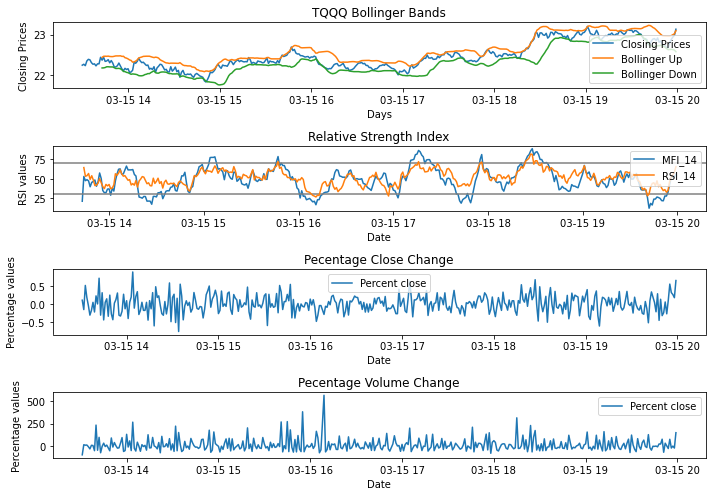

2023-03-16


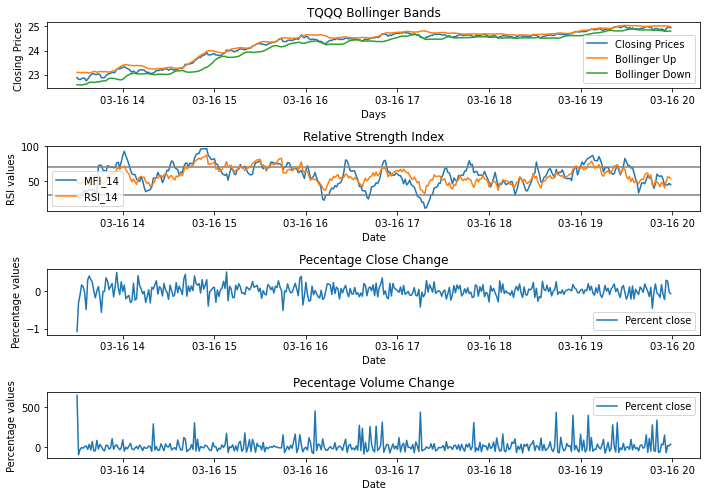

2023-03-17


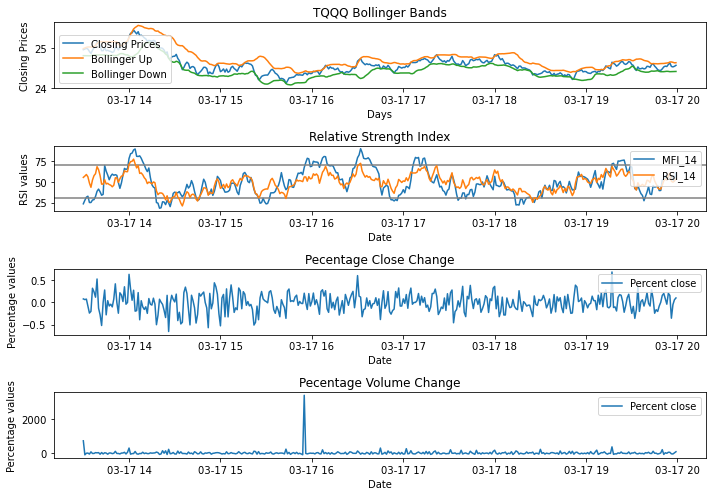

2023-03-20


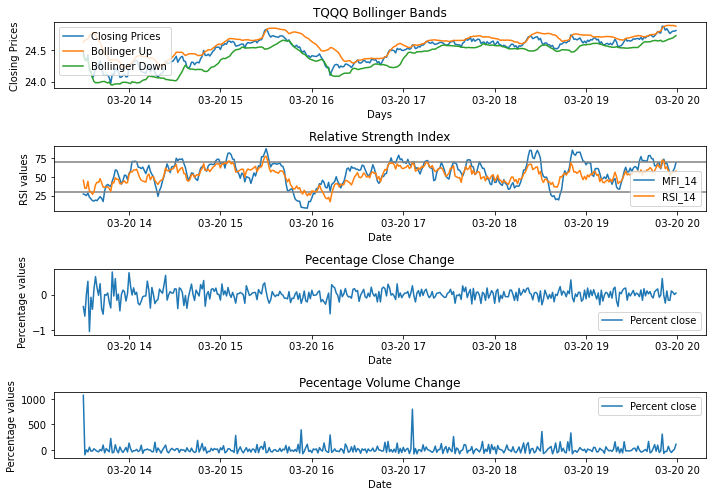

2023-03-21


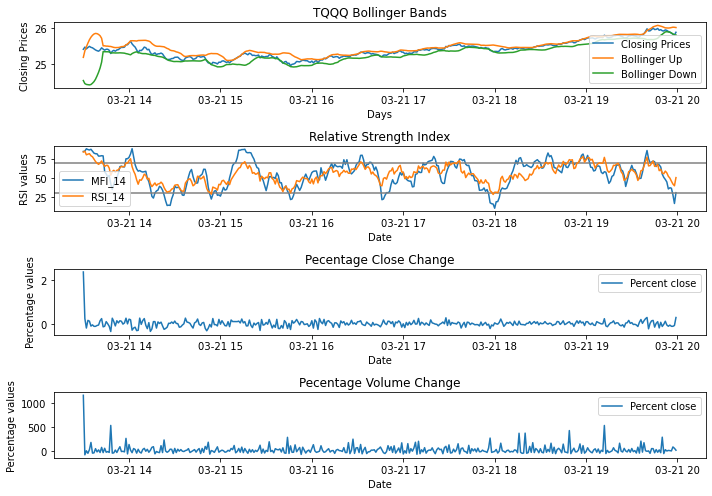

2023-03-22


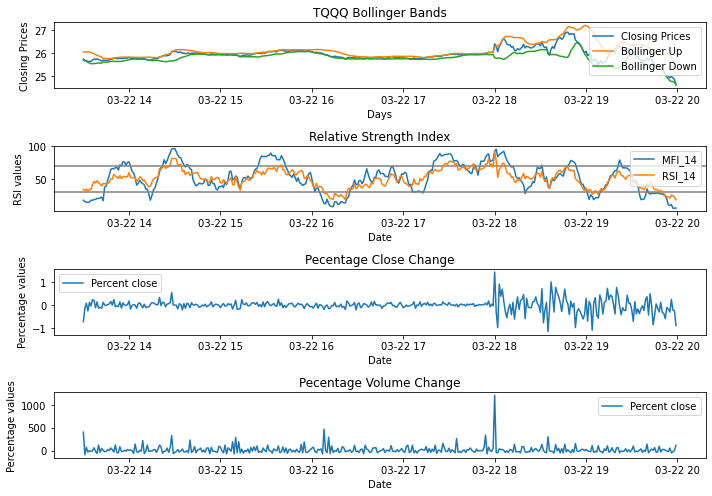

2023-03-23


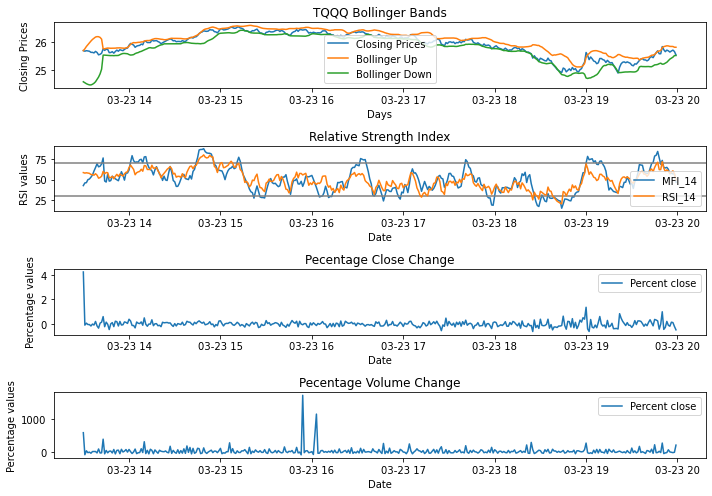

In [24]:
for i in np.unique(hist.index.date):
    print(i)
    sub_hist = hist[str(i):str(i)]

    
    fig = plt.figure(figsize=(10, 7))

    # Define position of 1st subplot
    ax = fig.add_subplot(4, 1, 1)

    # Set the title and axis labels
    plt.title(symbol + ' Bollinger Bands')
    plt.xlabel('Days')
    plt.ylabel('Closing Prices')
    plt.plot(sub_hist['close'], label='Closing Prices')
    plt.plot(sub_hist['bollinger_up_14'], label='Bollinger Up')
    plt.plot(sub_hist['bollinger_down_14'], label='Bollinger Down')
    plt.legend()

    # Define position of 2nd subplot
    bx = fig.add_subplot(4, 1, 2)

    # Set the title and axis labels
    plt.title('Relative Strength Index')
    plt.xlabel('Date')
    plt.ylabel('RSI values')
    
    plt.plot(sub_hist['MFI_14'], label='MFI_14')
    plt.axhline(y=30, color='grey', linestyle='-')
    plt.axhline(y=70, color='grey', linestyle='-')
    plt.plot(sub_hist['RSI_14'], label='RSI_14') 

    # Add a legend to the axis
    plt.legend()

    
    
    cx = fig.add_subplot(4, 1, 3)
    plt.title('Pecentage Close Change')
    plt.xlabel('Date')
    plt.ylabel('Percentage values')
    
    plt.plot(sub_hist['PER_close'], label='Percent close')

    plt.legend()
    

    cx = fig.add_subplot(4, 1, 4)
    plt.title('Pecentage Volume Change')
    plt.xlabel('Date')
    plt.ylabel('Percentage values')
    
    plt.plot(sub_hist['PER_volume'], label='Percent close')

    plt.legend()
    
    
    plt.tight_layout()
    plt.show()
    
    
   

In [25]:
hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume
Datetime,,,,,,,,,,,,
2023-03-15 09:30:00-04:00,22.170000,22.338699,22.100000,22.246799,22.246799,23455801,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-15 09:31:00-04:00,22.240000,22.299999,22.180000,22.270000,22.270000,1040095,NaN,NaN,NaN,NaN,0.104289,-95.565724
2023-03-15 09:32:00-04:00,22.270000,22.330000,22.180000,22.235001,22.235001,1209502,NaN,NaN,NaN,NaN,-0.157161,16.287647
2023-03-15 09:33:00-04:00,22.240000,22.360001,22.170000,22.349899,22.349899,1346112,NaN,NaN,NaN,NaN,0.516747,11.294731
2023-03-15 09:34:00-04:00,22.345900,22.480000,22.309999,22.390100,22.390100,1526564,NaN,NaN,NaN,NaN,0.179872,13.405422
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-23 15:55:00-04:00,25.690001,25.740000,25.590000,25.649900,25.649900,780910,57.233864,57.529196,25.852419,25.398652,-0.175518,-4.935407
2023-03-23 15:56:00-04:00,25.650000,25.722900,25.629999,25.688801,25.688801,647462,58.002279,59.371267,25.849546,25.434211,0.151659,-17.088781
2023-03-23 15:57:00-04:00,25.690001,25.725599,25.660000,25.719999,25.719999,478159,57.018960,60.838307,25.849366,25.467690,0.121448,-26.148716


In [26]:
for i in np.unique(hist.index.date):
    print(i)
    sub_hist = hist[str(i):str(i)]

    for i in range(5):
        sub_hist['high_'+str(i)] = sub_hist['high'].shift(-1-i)
    sub_hist['highest'] = sub_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
    sub_hist['success'] = np.where(sub_hist['close']*1.001 < sub_hist['highest'], 1,0) # 0.1%
    print(sub_hist)

2023-03-15
                                open       high        low      close  \
Datetime                                                                
2023-03-15 09:30:00-04:00  22.170000  22.338699  22.100000  22.246799   
2023-03-15 09:31:00-04:00  22.240000  22.299999  22.180000  22.270000   
2023-03-15 09:32:00-04:00  22.270000  22.330000  22.180000  22.235001   
2023-03-15 09:33:00-04:00  22.240000  22.360001  22.170000  22.349899   
2023-03-15 09:34:00-04:00  22.345900  22.480000  22.309999  22.390100   
...                              ...        ...        ...        ...   
2023-03-15 15:55:00-04:00  22.684999  22.820000  22.684299  22.807800   
2023-03-15 15:56:00-04:00  22.809999  22.889999  22.780001  22.879999   
2023-03-15 15:57:00-04:00  22.879999  22.959999  22.860001  22.940001   
2023-03-15 15:58:00-04:00  22.934999  22.999901  22.930201  22.980000   
2023-03-15 15:59:00-04:00  22.969999  23.139999  22.930000  23.129999   

                            adjclose   

<ipython-input-26-8bdf5fd8dc6a>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_hist['high_'+str(i)] = sub_hist['high'].shift(-1-i)
<ipython-input-26-8bdf5fd8dc6a>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_hist['highest'] = sub_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-26-8bdf5fd8dc6a>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import RFECV

from imblearn.over_sampling import SMOTE

In [28]:
sub_hist.dropna(axis=0,inplace=True)

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


In [80]:
sub_hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,high_0,high_1,high_2,high_3,high_4,highest,success
Datetime,,,,,,,,,,,,,,,,,,,
2023-03-23 09:30:00-04:00,25.703300,25.730000,25.580000,25.703300,25.703300,9088639,42.610223,58.686066,25.699148,24.589623,4.230741,584.444737,25.743401,25.729200,25.780001,25.719999,25.699900,25.780001,1
2023-03-23 09:31:00-04:00,25.709999,25.743401,25.680000,25.681000,25.681000,866325,45.912288,58.025310,25.767107,24.555236,-0.086762,-90.468045,25.729200,25.780001,25.719999,25.699900,25.660000,25.780001,1
2023-03-23 09:32:00-04:00,25.680799,25.729200,25.633699,25.699900,25.699900,1126703,46.215233,58.452262,25.848549,24.520922,0.073595,30.055464,25.780001,25.719999,25.699900,25.660000,25.680000,25.780001,1
2023-03-23 09:33:00-04:00,25.698299,25.780001,25.664000,25.690001,25.690001,824854,49.933931,58.118812,25.914741,24.496159,-0.038518,-26.790467,25.719999,25.699900,25.660000,25.680000,25.690001,25.719999,1
2023-03-23 09:34:00-04:00,25.700001,25.719999,25.640100,25.679899,25.679899,732403,50.746305,57.756738,25.983136,24.479179,-0.039320,-11.208165,25.699900,25.660000,25.680000,25.690001,25.687300,25.699900,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-23 15:50:00-04:00,25.600000,25.930000,25.590000,25.845699,25.845699,2335781,73.742129,72.289236,25.804644,25.217713,0.999215,267.227097,25.870001,25.730000,25.750000,25.740000,25.740000,25.870001,0
2023-03-23 15:51:00-04:00,25.850000,25.870001,25.700001,25.733999,25.733999,1041907,65.067147,64.307989,25.844312,25.223616,-0.432180,-55.393635,25.730000,25.750000,25.740000,25.740000,25.722900,25.750000,0
2023-03-23 15:52:00-04:00,25.730000,25.730000,25.660999,25.664499,25.664499,680797,64.409943,59.878213,25.857292,25.252707,-0.270071,-34.658564,25.750000,25.740000,25.740000,25.722900,25.725599,25.750000,1


In [29]:
X_df = sub_hist[['close','volume','MFI_14','RSI_14','bollinger_up_14','bollinger_down_14','PER_close','PER_volume']]
y_df = sub_hist['success']

In [30]:
X_df

,close,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume
Datetime,,,,,,,,
2023-03-23 09:30:00-04:00,25.703300,9088639,42.610223,58.686066,25.699148,24.589623,4.230741,584.444737
2023-03-23 09:31:00-04:00,25.681000,866325,45.912288,58.025310,25.767107,24.555236,-0.086762,-90.468045
2023-03-23 09:32:00-04:00,25.699900,1126703,46.215233,58.452262,25.848549,24.520922,0.073595,30.055464
2023-03-23 09:33:00-04:00,25.690001,824854,49.933931,58.118812,25.914741,24.496159,-0.038518,-26.790467
2023-03-23 09:34:00-04:00,25.679899,732403,50.746305,57.756738,25.983136,24.479179,-0.039320,-11.208165
...,...,...,...,...,...,...,...,...
2023-03-23 15:50:00-04:00,25.845699,2335781,73.742129,72.289236,25.804644,25.217713,0.999215,267.227097
2023-03-23 15:51:00-04:00,25.733999,1041907,65.067147,64.307989,25.844312,25.223616,-0.432180,-55.393635
2023-03-23 15:52:00-04:00,25.664499,680797,64.409943,59.878213,25.857292,25.252707,-0.270071,-34.658564


In [31]:
os = SMOTE(random_state=1)
#x_train, x_test, y_train, y_test = train_test_split(x_df, y_df, test_size=0.2, random_state=1)
#columns = x_train.columns
os_X_df, os_y_df=os.fit_resample(X_df, y_df)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(os_X_df,
                                  os_y_df,
                                  test_size=0.3,
                                  random_state=1)

In [33]:
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVC', SVC()))
models.append(('GNB', GaussianNB()))
models.append(('RF', RandomForestClassifier()))
models.append(('GB', GradientBoostingClassifier()))

In [34]:
names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(roc_auc_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0   LR  0.500000
1  KNN  0.637927
2  SVC  0.506556
3  GNB  0.552449
4   RF  0.775359
5   GB  0.753093


In [35]:
names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0   LR  0.477778
1  KNN  0.638889
2  SVC  0.516667
3  GNB  0.566667
4   RF  0.766667
5   GB  0.755556


In [36]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
rf_v1 = RandomForestClassifier()


n_scores = cross_val_score(rf_v1, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
# report performance
print('AUC: %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

AUC: 0.775 (0.041)


In [37]:
n_scores

array([0.80952381, 0.73809524, 0.72619048, 0.79761905, 0.73809524,
       0.83333333, 0.70238095, 0.75      , 0.85714286, 0.75      ,
       0.79761905, 0.78571429, 0.76190476, 0.76190476, 0.80952381])

In [38]:
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 100, num = 10)]
max_depth.append(None)
min_samples_split = [1, 3, 5]
min_samples_leaf = [1, 3, 5]
bootstrap = [True]

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}




rf_v2 = RandomForestClassifier()

rf_random = RandomizedSearchCV(estimator = rf_v2, param_distributions = random_grid, n_iter = 10, cv = 5, verbose=2, random_state=1, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\hkim\AppData\Roaming\Python\Python39\site-packages\sklearn\ensemble\_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 3, 5],
                                        'min_samples_split': [1, 3, 5],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=1, verbose=2)

In [39]:
y_pred = rf_random.predict(X_test)
accuracy_score(y_test, y_pred)

0.7944444444444444

In [40]:
sub_hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,high_0,high_1,high_2,high_3,high_4,highest,success
Datetime,,,,,,,,,,,,,,,,,,,
2023-03-23 09:30:00-04:00,25.703300,25.730000,25.580000,25.703300,25.703300,9088639,42.610223,58.686066,25.699148,24.589623,4.230741,584.444737,25.743401,25.729200,25.780001,25.719999,25.699900,25.780001,1
2023-03-23 09:31:00-04:00,25.709999,25.743401,25.680000,25.681000,25.681000,866325,45.912288,58.025310,25.767107,24.555236,-0.086762,-90.468045,25.729200,25.780001,25.719999,25.699900,25.660000,25.780001,1
2023-03-23 09:32:00-04:00,25.680799,25.729200,25.633699,25.699900,25.699900,1126703,46.215233,58.452262,25.848549,24.520922,0.073595,30.055464,25.780001,25.719999,25.699900,25.660000,25.680000,25.780001,1
2023-03-23 09:33:00-04:00,25.698299,25.780001,25.664000,25.690001,25.690001,824854,49.933931,58.118812,25.914741,24.496159,-0.038518,-26.790467,25.719999,25.699900,25.660000,25.680000,25.690001,25.719999,1
2023-03-23 09:34:00-04:00,25.700001,25.719999,25.640100,25.679899,25.679899,732403,50.746305,57.756738,25.983136,24.479179,-0.039320,-11.208165,25.699900,25.660000,25.680000,25.690001,25.687300,25.699900,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-23 15:50:00-04:00,25.600000,25.930000,25.590000,25.845699,25.845699,2335781,73.742129,72.289236,25.804644,25.217713,0.999215,267.227097,25.870001,25.730000,25.750000,25.740000,25.740000,25.870001,0
2023-03-23 15:51:00-04:00,25.850000,25.870001,25.700001,25.733999,25.733999,1041907,65.067147,64.307989,25.844312,25.223616,-0.432180,-55.393635,25.730000,25.750000,25.740000,25.740000,25.722900,25.750000,0
2023-03-23 15:52:00-04:00,25.730000,25.730000,25.660999,25.664499,25.664499,680797,64.409943,59.878213,25.857292,25.252707,-0.270071,-34.658564,25.750000,25.740000,25.740000,25.722900,25.725599,25.750000,1


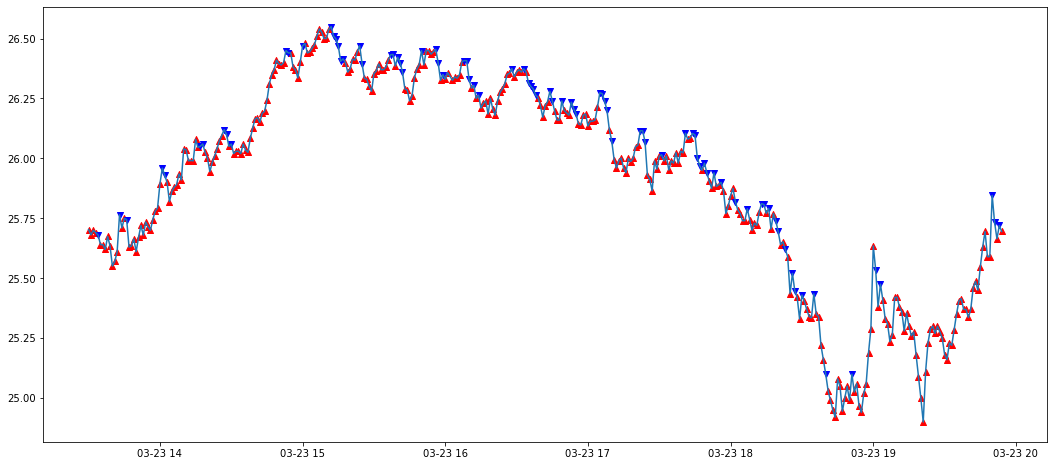

In [41]:
plt.figure(figsize=(18,8))
plt.plot(sub_hist['close'], label='Closing Prices')
plt.scatter(sub_hist[sub_hist['success']==1]['close'].index, sub_hist[sub_hist['success']==1]['close'],label='success', marker = '^', color = 'r')
plt.scatter(sub_hist[sub_hist['success']==0]['close'].index, sub_hist[sub_hist['success']==0]['close'],label='fail', marker = 'v', color = 'b')


In [42]:
sub_hist[sub_hist['success']==0]['close'].index

DatetimeIndex(['2023-03-23 09:34:00-04:00', '2023-03-23 09:43:00-04:00',
               '2023-03-23 09:46:00-04:00', '2023-03-23 10:01:00-04:00',
               '2023-03-23 10:02:00-04:00', '2023-03-23 10:17:00-04:00',
               '2023-03-23 10:18:00-04:00', '2023-03-23 10:27:00-04:00',
               '2023-03-23 10:28:00-04:00', '2023-03-23 10:30:00-04:00',
               '2023-03-23 10:53:00-04:00', '2023-03-23 10:54:00-04:00',
               '2023-03-23 11:00:00-04:00', '2023-03-23 11:12:00-04:00',
               '2023-03-23 11:13:00-04:00', '2023-03-23 11:14:00-04:00',
               '2023-03-23 11:15:00-04:00', '2023-03-23 11:16:00-04:00',
               '2023-03-23 11:17:00-04:00', '2023-03-23 11:24:00-04:00',
               '2023-03-23 11:25:00-04:00', '2023-03-23 11:37:00-04:00',
               '2023-03-23 11:38:00-04:00', '2023-03-23 11:40:00-04:00',
               '2023-03-23 11:41:00-04:00', '2023-03-23 11:42:00-04:00',
               '2023-03-23 11:50:00-04:00', '2023-0

In [43]:
sub_hist.groupby(by = 'success').count()

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,high_0,high_1,high_2,high_3,high_4,highest
success,,,,,,,,,,,,,,,,,,
0,84,84,84,84,84,84,84,84,84,84,84,84,84,84,84,84,84,84
1,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300


In [44]:
len(sub_hist[sub_hist['success']==1])/len(sub_hist['success'])

0.78125

In [45]:
len(sub_hist['success']), len(sub_hist[sub_hist['success']==1])

(384, 300)

In [46]:
sub_hist.groupby(by = 'success').mean()

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,high_0,high_1,high_2,high_3,high_4,highest
success,,,,,,,,,,,,,,,,,,
0,26.078431,26.121193,26.043513,26.084450,26.084450,465995.750000,53.158325,51.810569,26.193093,25.916038,0.025804,16.019588,26.094051,26.063711,26.044725,26.028088,26.021919,26.096589
1,25.876267,25.914855,25.835634,25.874228,25.874228,501489.376667,49.393906,49.587743,26.045151,25.690284,0.007077,23.183548,25.922488,25.930915,25.936219,25.940680,25.942274,25.990618


In [47]:
sub_hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,high_0,high_1,high_2,high_3,high_4,highest,success
Datetime,,,,,,,,,,,,,,,,,,,
2023-03-23 09:30:00-04:00,25.703300,25.730000,25.580000,25.703300,25.703300,9088639,42.610223,58.686066,25.699148,24.589623,4.230741,584.444737,25.743401,25.729200,25.780001,25.719999,25.699900,25.780001,1
2023-03-23 09:31:00-04:00,25.709999,25.743401,25.680000,25.681000,25.681000,866325,45.912288,58.025310,25.767107,24.555236,-0.086762,-90.468045,25.729200,25.780001,25.719999,25.699900,25.660000,25.780001,1
2023-03-23 09:32:00-04:00,25.680799,25.729200,25.633699,25.699900,25.699900,1126703,46.215233,58.452262,25.848549,24.520922,0.073595,30.055464,25.780001,25.719999,25.699900,25.660000,25.680000,25.780001,1
2023-03-23 09:33:00-04:00,25.698299,25.780001,25.664000,25.690001,25.690001,824854,49.933931,58.118812,25.914741,24.496159,-0.038518,-26.790467,25.719999,25.699900,25.660000,25.680000,25.690001,25.719999,1
2023-03-23 09:34:00-04:00,25.700001,25.719999,25.640100,25.679899,25.679899,732403,50.746305,57.756738,25.983136,24.479179,-0.039320,-11.208165,25.699900,25.660000,25.680000,25.690001,25.687300,25.699900,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-23 15:50:00-04:00,25.600000,25.930000,25.590000,25.845699,25.845699,2335781,73.742129,72.289236,25.804644,25.217713,0.999215,267.227097,25.870001,25.730000,25.750000,25.740000,25.740000,25.870001,0
2023-03-23 15:51:00-04:00,25.850000,25.870001,25.700001,25.733999,25.733999,1041907,65.067147,64.307989,25.844312,25.223616,-0.432180,-55.393635,25.730000,25.750000,25.740000,25.740000,25.722900,25.750000,0
2023-03-23 15:52:00-04:00,25.730000,25.730000,25.660999,25.664499,25.664499,680797,64.409943,59.878213,25.857292,25.252707,-0.270071,-34.658564,25.750000,25.740000,25.740000,25.722900,25.725599,25.750000,1


## last day data, resampling, 

In [48]:
sub_hist.dropna(axis=0,inplace=True)

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


In [49]:
X_df = sub_hist[['close','volume','MFI_14','RSI_14','bollinger_up_14','bollinger_down_14','PER_close','PER_volume']]
y_df = sub_hist['success']

In [50]:
X_df

,close,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume
Datetime,,,,,,,,
2023-03-23 09:30:00-04:00,25.703300,9088639,42.610223,58.686066,25.699148,24.589623,4.230741,584.444737
2023-03-23 09:31:00-04:00,25.681000,866325,45.912288,58.025310,25.767107,24.555236,-0.086762,-90.468045
2023-03-23 09:32:00-04:00,25.699900,1126703,46.215233,58.452262,25.848549,24.520922,0.073595,30.055464
2023-03-23 09:33:00-04:00,25.690001,824854,49.933931,58.118812,25.914741,24.496159,-0.038518,-26.790467
2023-03-23 09:34:00-04:00,25.679899,732403,50.746305,57.756738,25.983136,24.479179,-0.039320,-11.208165
...,...,...,...,...,...,...,...,...
2023-03-23 15:50:00-04:00,25.845699,2335781,73.742129,72.289236,25.804644,25.217713,0.999215,267.227097
2023-03-23 15:51:00-04:00,25.733999,1041907,65.067147,64.307989,25.844312,25.223616,-0.432180,-55.393635
2023-03-23 15:52:00-04:00,25.664499,680797,64.409943,59.878213,25.857292,25.252707,-0.270071,-34.658564


In [51]:
os = SMOTE(random_state=1)
#x_train, x_test, y_train, y_test = train_test_split(x_df, y_df, test_size=0.2, random_state=1)
#columns = x_train.columns
os_X_df, os_y_df=os.fit_resample(X_df, y_df)

In [52]:
X_train, X_test, y_train, y_test = train_test_split(os_X_df,
                                  os_y_df,
                                  test_size=0.3,
                                  random_state=1)

In [53]:
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVC', SVC()))
models.append(('GNB', GaussianNB()))
models.append(('RF', RandomForestClassifier()))
models.append(('GB', GradientBoostingClassifier()))

In [54]:
names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(roc_auc_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0   LR  0.500000
1  KNN  0.637927
2  SVC  0.506556
3  GNB  0.552449
4   RF  0.791811
5   GB  0.758906


In [55]:
names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0   LR  0.477778
1  KNN  0.638889
2  SVC  0.516667
3  GNB  0.566667
4   RF  0.800000
5   GB  0.722222


In [56]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
rf_v1 = RandomForestClassifier()


n_scores = cross_val_score(rf_v1, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
# report performance
print('AUC: %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

AUC: 0.771 (0.043)


In [57]:
n_scores

array([0.79761905, 0.75      , 0.69047619, 0.77380952, 0.76190476,
       0.79761905, 0.71428571, 0.73809524, 0.85714286, 0.76190476,
       0.79761905, 0.77380952, 0.79761905, 0.72619048, 0.83333333])

In [58]:
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 100, num = 10)]
max_depth.append(None)
min_samples_split = [1, 3, 5]
min_samples_leaf = [1, 3, 5]
bootstrap = [True]

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}




rf_v2 = RandomForestClassifier()

rf_random = RandomizedSearchCV(estimator = rf_v2, param_distributions = random_grid, n_iter = 10, cv = 5, verbose=2, random_state=1, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\hkim\AppData\Roaming\Python\Python39\site-packages\sklearn\ensemble\_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 3, 5],
                                        'min_samples_split': [1, 3, 5],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=1, verbose=2)

In [59]:
y_pred = rf_random.predict(X_test)
accuracy_score(y_test, y_pred)

0.8

## 8 DAYS FOR TRAINING, 2 DAYS FOR TESTING

In [60]:
hist_ml = hist.copy()

In [61]:
hist_ml.dropna(axis=0,inplace=True)

In [62]:
for i in range(5):
    hist_ml['high_'+str(i)] = hist_ml['high'].shift(-1-i)
hist_ml['highest'] = hist_ml[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
hist_ml['success'] = np.where(hist_ml['close']*1.001 < hist_ml['highest'], 1,0)

In [63]:
hist_ml

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,high_0,high_1,high_2,high_3,high_4,highest,success
Datetime,,,,,,,,,,,,,,,,,,,
2023-03-15 09:44:00-04:00,22.368000,22.440001,22.311899,22.440001,22.440001,588930,53.081919,64.533683,22.465472,22.180943,0.312918,-1.688357,22.500000,22.369900,22.410000,22.409599,22.379900,22.500000,1
2023-03-15 09:45:00-04:00,22.450001,22.500000,22.309999,22.340000,22.340000,787507,47.660908,53.318572,22.467301,22.189114,-0.445634,33.718269,22.369900,22.410000,22.409599,22.379900,22.375000,22.410000,1
2023-03-15 09:46:00-04:00,22.330000,22.369900,22.219999,22.350000,22.350000,757694,48.974637,54.176204,22.464989,22.207855,0.044764,-3.785744,22.410000,22.409599,22.379900,22.375000,22.319500,22.410000,1
2023-03-15 09:47:00-04:00,22.360001,22.410000,22.225000,22.382000,22.382000,852387,47.384414,56.904598,22.469444,22.207985,0.143175,12.497525,22.409599,22.379900,22.375000,22.319500,22.285000,22.409599,1
2023-03-15 09:48:00-04:00,22.379999,22.409599,22.260000,22.305000,22.305000,684644,39.808624,49.298243,22.460965,22.204307,-0.344025,-19.679207,22.379900,22.375000,22.319500,22.285000,22.239901,22.379900,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-23 15:55:00-04:00,25.690001,25.740000,25.590000,25.649900,25.649900,780910,57.233864,57.529196,25.852419,25.398652,-0.175518,-4.935407,25.722900,25.725599,25.721001,25.680000,NaN,25.725599,1
2023-03-23 15:56:00-04:00,25.650000,25.722900,25.629999,25.688801,25.688801,647462,58.002279,59.371267,25.849546,25.434211,0.151659,-17.088781,25.725599,25.721001,25.680000,NaN,NaN,25.725599,1
2023-03-23 15:57:00-04:00,25.690001,25.725599,25.660000,25.719999,25.719999,478159,57.018960,60.838307,25.849366,25.467690,0.121448,-26.148716,25.721001,25.680000,NaN,NaN,NaN,25.721001,0


In [64]:
hist_ml.dropna(axis=0,inplace=True)

In [65]:
X_df = hist_ml[['close','volume','MFI_14','RSI_14','bollinger_up_14','bollinger_down_14','PER_close','PER_volume']]
y_df = hist_ml['success']

In [66]:
X_df

,close,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume
Datetime,,,,,,,,
2023-03-15 09:44:00-04:00,22.440001,588930,53.081919,64.533683,22.465472,22.180943,0.312918,-1.688357
2023-03-15 09:45:00-04:00,22.340000,787507,47.660908,53.318572,22.467301,22.189114,-0.445634,33.718269
2023-03-15 09:46:00-04:00,22.350000,757694,48.974637,54.176204,22.464989,22.207855,0.044764,-3.785744
2023-03-15 09:47:00-04:00,22.382000,852387,47.384414,56.904598,22.469444,22.207985,0.143175,12.497525
2023-03-15 09:48:00-04:00,22.305000,684644,39.808624,49.298243,22.460965,22.204307,-0.344025,-19.679207
...,...,...,...,...,...,...,...,...
2023-03-23 15:50:00-04:00,25.845699,2335781,73.742129,72.289236,25.804644,25.217713,0.999215,267.227097
2023-03-23 15:51:00-04:00,25.733999,1041907,65.067147,64.307989,25.844312,25.223616,-0.432180,-55.393635
2023-03-23 15:52:00-04:00,25.664499,680797,64.409943,59.878213,25.857292,25.252707,-0.270071,-34.658564


In [67]:
os = SMOTE(random_state=1)
#x_train, x_test, y_train, y_test = train_test_split(x_df, y_df, test_size=0.2, random_state=1)
#columns = x_train.columns
os_X_df, os_y_df=os.fit_resample(X_df, y_df)

In [68]:
X_train, X_test, y_train, y_test = train_test_split(os_X_df,
                                  os_y_df,
                                  test_size=0.1,
                                  random_state=1)

In [69]:
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVC', SVC()))
models.append(('GNB', GaussianNB()))
models.append(('RF', RandomForestClassifier()))
models.append(('GB', GradientBoostingClassifier()))

In [70]:
names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(roc_auc_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0   LR  0.597974
1  KNN  0.623124
2  SVC  0.540576
3  GNB  0.502252
4   RF  0.790922
5   GB  0.739864


In [71]:
names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0   LR  0.593458
1  KNN  0.623832
2  SVC  0.532710
3  GNB  0.528037
4   RF  0.799065
5   GB  0.742991


In [72]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
rf_v1 = RandomForestClassifier()


n_scores = cross_val_score(rf_v1, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
# report performance
print('AUC: %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

AUC: 0.767 (0.016)


In [73]:
n_scores

array([0.77561608, 0.77431907, 0.77532468, 0.76103896, 0.74025974,
       0.72503243, 0.76653696, 0.78051948, 0.76753247, 0.79090909,
       0.77561608, 0.76783398, 0.75974026, 0.77142857, 0.76883117])

In [74]:
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 100, num = 10)]
max_depth.append(None)
min_samples_split = [1, 3, 5]
min_samples_leaf = [1, 3, 5]
bootstrap = [True]

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}




rf_v2 = RandomForestClassifier()

rf_random = RandomizedSearchCV(estimator = rf_v2, param_distributions = random_grid, n_iter = 10, cv = 5, verbose=2, random_state=1, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\hkim\AppData\Roaming\Python\Python39\site-packages\sklearn\ensemble\_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 3, 5],
                                        'min_samples_split': [1, 3, 5],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=1, verbose=2)

In [75]:
y_pred = rf_random.predict(X_test)
accuracy_score(y_test, y_pred)

0.8014018691588785

## ml - with under_BBL

In [82]:
hist_ml['under_BBL'] = np.where(hist_ml['close'] < hist_ml['bollinger_down_14'], 1, 0)

In [83]:
X_df = hist_ml[['close','volume','MFI_14','RSI_14','bollinger_up_14','bollinger_down_14','PER_close','PER_volume','under_BBL']]
y_df = hist_ml['success']

In [84]:
X_df

,close,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,under_BBL
Datetime,,,,,,,,,
2023-03-15 09:44:00-04:00,22.440001,588930,53.081919,64.533683,22.465472,22.180943,0.312918,-1.688357,0
2023-03-15 09:45:00-04:00,22.340000,787507,47.660908,53.318572,22.467301,22.189114,-0.445634,33.718269,0
2023-03-15 09:46:00-04:00,22.350000,757694,48.974637,54.176204,22.464989,22.207855,0.044764,-3.785744,0
2023-03-15 09:47:00-04:00,22.382000,852387,47.384414,56.904598,22.469444,22.207985,0.143175,12.497525,0
2023-03-15 09:48:00-04:00,22.305000,684644,39.808624,49.298243,22.460965,22.204307,-0.344025,-19.679207,0
...,...,...,...,...,...,...,...,...,...
2023-03-23 15:50:00-04:00,25.845699,2335781,73.742129,72.289236,25.804644,25.217713,0.999215,267.227097,0
2023-03-23 15:51:00-04:00,25.733999,1041907,65.067147,64.307989,25.844312,25.223616,-0.432180,-55.393635,0
2023-03-23 15:52:00-04:00,25.664499,680797,64.409943,59.878213,25.857292,25.252707,-0.270071,-34.658564,0


In [85]:
os = SMOTE(random_state=1)
#x_train, x_test, y_train, y_test = train_test_split(x_df, y_df, test_size=0.2, random_state=1)
#columns = x_train.columns
os_X_df, os_y_df=os.fit_resample(X_df, y_df)

In [86]:
X_train, X_test, y_train, y_test = train_test_split(os_X_df,
                                  os_y_df,
                                  test_size=0.1,
                                  random_state=1)

In [87]:
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVC', SVC()))
models.append(('GNB', GaussianNB()))
models.append(('RF', RandomForestClassifier()))
models.append(('GB', GradientBoostingClassifier()))

In [88]:
names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(roc_auc_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0   LR  0.597974
1  KNN  0.623124
2  SVC  0.540576
3  GNB  0.502252
4   RF  0.779726
5   GB  0.717472


In [89]:
names = []
scores = []
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))
    names.append(name)
tr_split = pd.DataFrame({'Name': names, 'Score': scores})
print(tr_split)

  Name     Score
0   LR  0.593458
1  KNN  0.623832
2  SVC  0.532710
3  GNB  0.528037
4   RF  0.796729
5   GB  0.719626


In [90]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
rf_v1 = RandomForestClassifier()


n_scores = cross_val_score(rf_v1, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
# report performance
print('AUC: %.3f (%.3f)' % (np.mean(n_scores), np.std(n_scores)))

AUC: 0.765 (0.014)


In [91]:
n_scores

array([0.76653696, 0.78728923, 0.76363636, 0.77012987, 0.74675325,
       0.73411154, 0.77172503, 0.78441558, 0.75714286, 0.78571429,
       0.77302205, 0.76394293, 0.74935065, 0.76363636, 0.75584416])

In [92]:
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 100, num = 10)]
max_depth.append(None)
min_samples_split = [1, 3, 5]
min_samples_leaf = [1, 3, 5]
bootstrap = [True]

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}




rf_v2 = RandomForestClassifier()

rf_random = RandomizedSearchCV(estimator = rf_v2, param_distributions = random_grid, n_iter = 10, cv = 5, verbose=2, random_state=1, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\hkim\AppData\Roaming\Python\Python39\site-packages\sklearn\ensemble\_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 3, 5],
                                        'min_samples_split': [1, 3, 5],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=1, verbose=2)

In [93]:
y_pred = rf_random.predict(X_test)
accuracy_score(y_test, y_pred)

0.7990654205607477

In [94]:
hist['under_BBL'] = np.where(hist['close'] < hist['bollinger_down_14'], 1, 0)

In [95]:
hist

,open,high,low,close,adjclose,volume,MFI_14,RSI_14,bollinger_up_14,bollinger_down_14,PER_close,PER_volume,under_BBL
Datetime,,,,,,,,,,,,,
2023-03-15 09:30:00-04:00,22.170000,22.338699,22.100000,22.246799,22.246799,23455801,NaN,NaN,NaN,NaN,NaN,NaN,0
2023-03-15 09:31:00-04:00,22.240000,22.299999,22.180000,22.270000,22.270000,1040095,NaN,NaN,NaN,NaN,0.104289,-95.565724,0
2023-03-15 09:32:00-04:00,22.270000,22.330000,22.180000,22.235001,22.235001,1209502,NaN,NaN,NaN,NaN,-0.157161,16.287647,0
2023-03-15 09:33:00-04:00,22.240000,22.360001,22.170000,22.349899,22.349899,1346112,NaN,NaN,NaN,NaN,0.516747,11.294731,0
2023-03-15 09:34:00-04:00,22.345900,22.480000,22.309999,22.390100,22.390100,1526564,NaN,NaN,NaN,NaN,0.179872,13.405422,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-23 15:55:00-04:00,25.690001,25.740000,25.590000,25.649900,25.649900,780910,57.233864,57.529196,25.852419,25.398652,-0.175518,-4.935407,0
2023-03-23 15:56:00-04:00,25.650000,25.722900,25.629999,25.688801,25.688801,647462,58.002279,59.371267,25.849546,25.434211,0.151659,-17.088781,0
2023-03-23 15:57:00-04:00,25.690001,25.725599,25.660000,25.719999,25.719999,478159,57.018960,60.838307,25.849366,25.467690,0.121448,-26.148716,0


2023-03-15
15 13 0.8666666666666667


<ipython-input-96-e5861f2fe5e3>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['high_'+str(i)] = daily_hist['high'].shift(-1-i)
<ipython-input-96-e5861f2fe5e3>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['highest'] = daily_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-96-e5861f2fe5e3>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

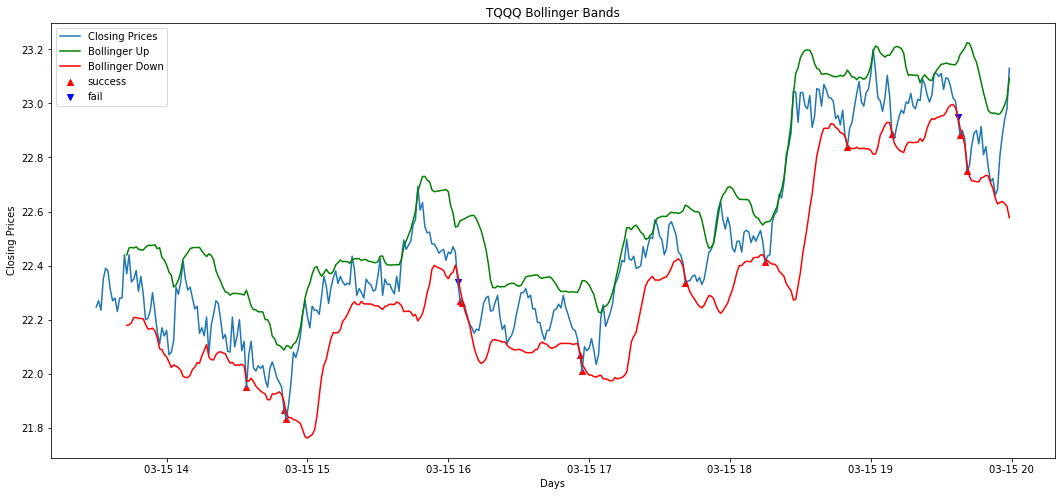

2023-03-16
8 8 1.0


<ipython-input-96-e5861f2fe5e3>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['high_'+str(i)] = daily_hist['high'].shift(-1-i)
<ipython-input-96-e5861f2fe5e3>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['highest'] = daily_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-96-e5861f2fe5e3>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

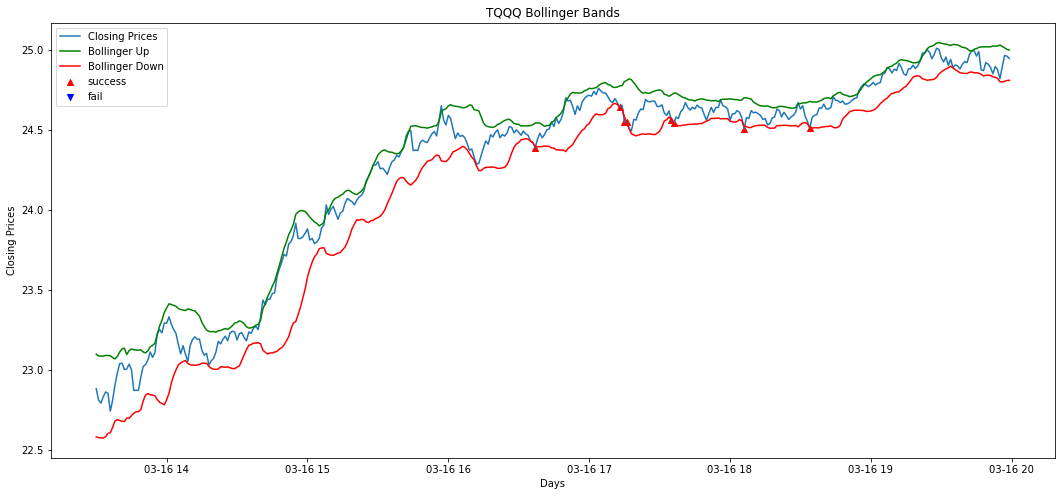

2023-03-17
16 15 0.9375


<ipython-input-96-e5861f2fe5e3>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['high_'+str(i)] = daily_hist['high'].shift(-1-i)
<ipython-input-96-e5861f2fe5e3>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['highest'] = daily_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-96-e5861f2fe5e3>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

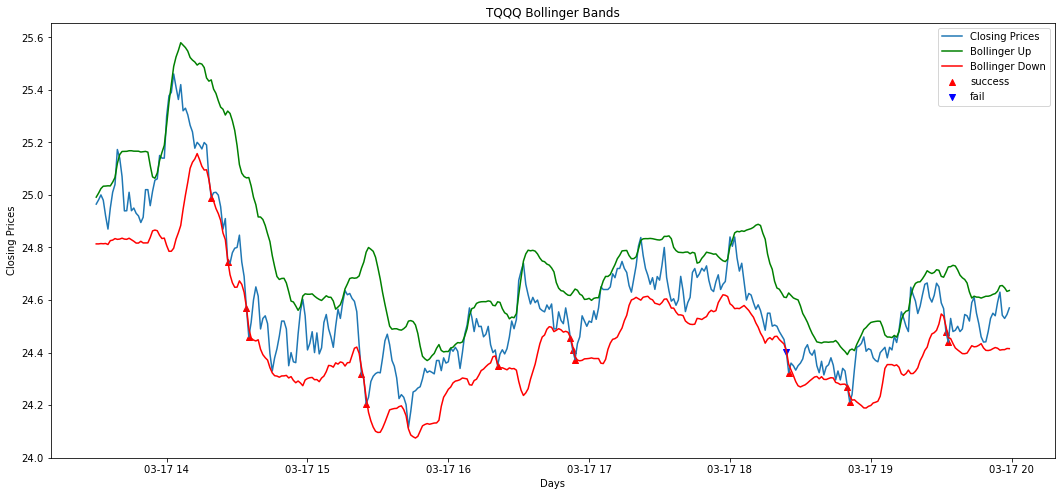

2023-03-20
13 10 0.7692307692307693


<ipython-input-96-e5861f2fe5e3>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['high_'+str(i)] = daily_hist['high'].shift(-1-i)
<ipython-input-96-e5861f2fe5e3>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['highest'] = daily_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-96-e5861f2fe5e3>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

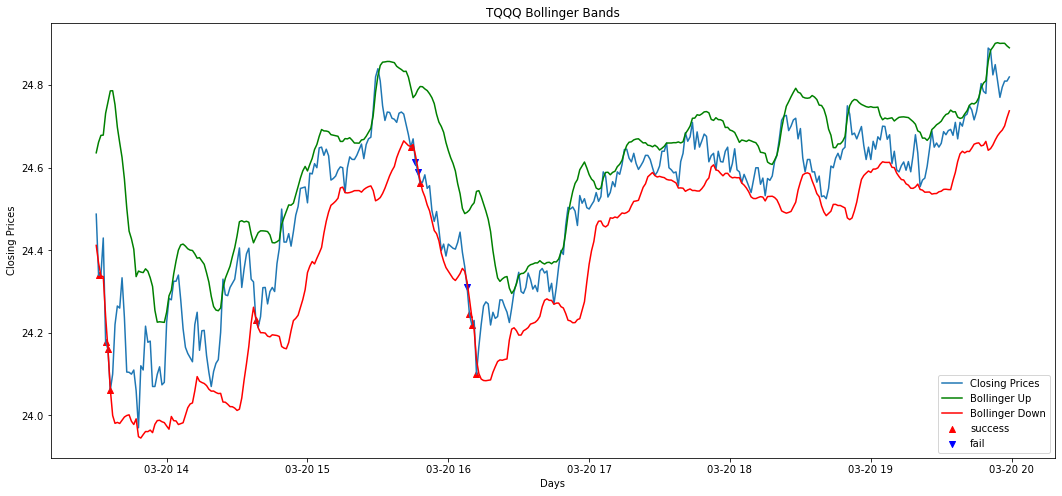

2023-03-21
17 12 0.7058823529411765


<ipython-input-96-e5861f2fe5e3>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['high_'+str(i)] = daily_hist['high'].shift(-1-i)
<ipython-input-96-e5861f2fe5e3>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['highest'] = daily_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-96-e5861f2fe5e3>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

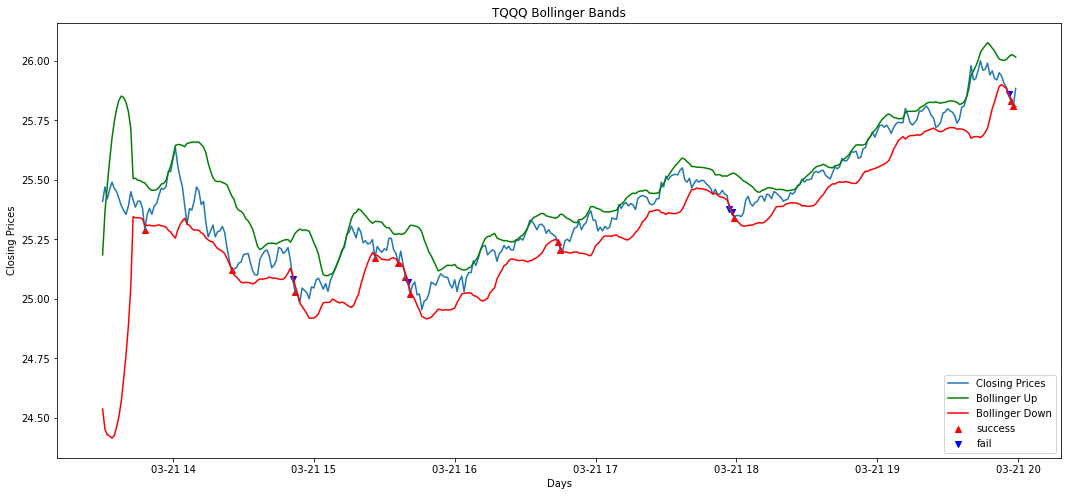

2023-03-22
15 12 0.8


<ipython-input-96-e5861f2fe5e3>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['high_'+str(i)] = daily_hist['high'].shift(-1-i)
<ipython-input-96-e5861f2fe5e3>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['highest'] = daily_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-96-e5861f2fe5e3>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

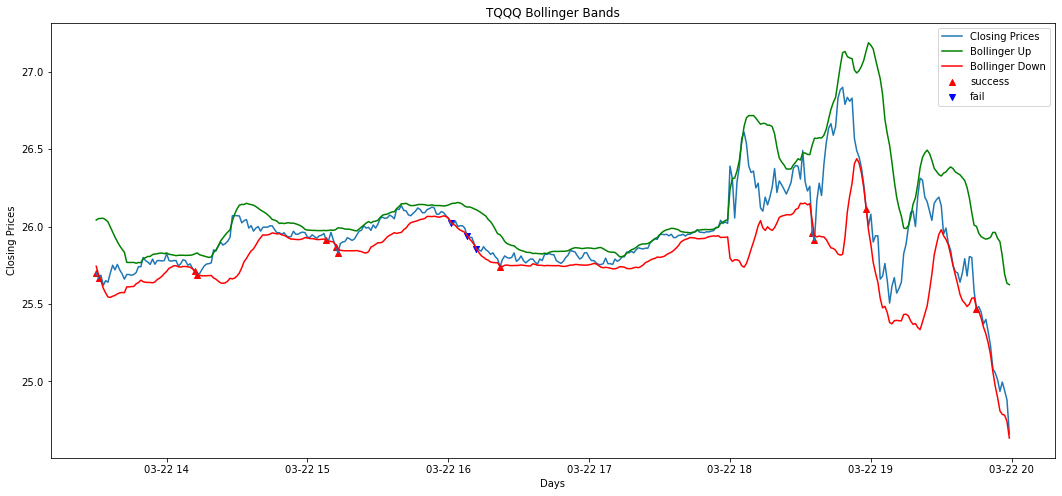

2023-03-23
20 17 0.85


<ipython-input-96-e5861f2fe5e3>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['high_'+str(i)] = daily_hist['high'].shift(-1-i)
<ipython-input-96-e5861f2fe5e3>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_hist['highest'] = daily_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
<ipython-input-96-e5861f2fe5e3>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

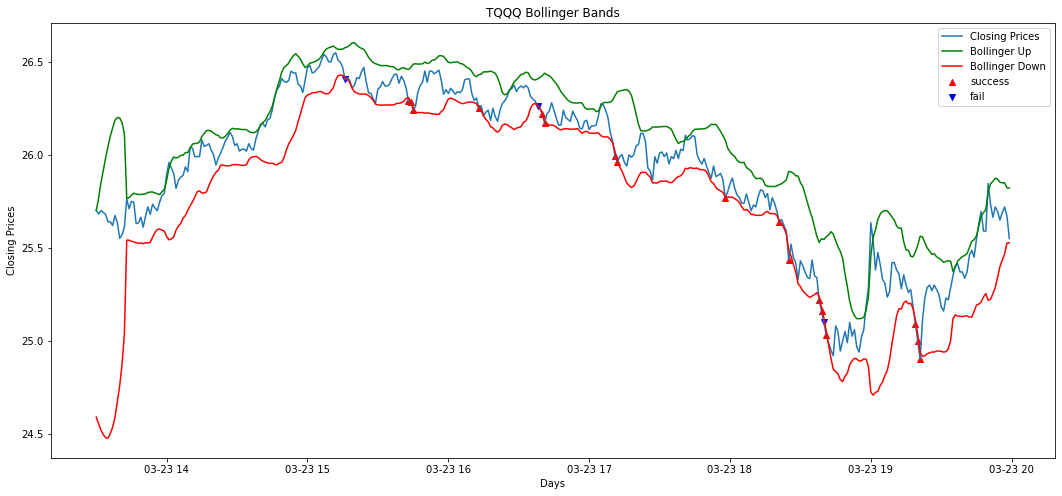

In [96]:
for i in np.unique(hist.index.date):
    print(i)
    daily_hist = hist[str(i):str(i)]

    plt.figure(figsize=(18,8))
    plt.title(symbol + ' Bollinger Bands')
    plt.xlabel('Days')
    plt.ylabel('Closing Prices')
    plt.plot(daily_hist['close'], label='Closing Prices')
    plt.plot(daily_hist['bollinger_up_14'], label='Bollinger Up', c='g')
    plt.plot(daily_hist['bollinger_down_14'], label='Bollinger Down', c='r')
#     plt.scatter(sub_hist[sub_hist['under_BBL']==1]['Close'].index, sub_hist[sub_hist['under_BBL']==1]['Close'],label='under bolligerband_low')

    # plt.plot(closing_prices, label='Closing Prices')
    # plt.plot(bollinger_up, label='Bollinger Up', c='g')
    # plt.plot(bollinger_down, label='Bollinger Down', c='r')

    
    
    for i in range(5):
        daily_hist['high_'+str(i)] = daily_hist['high'].shift(-1-i)
    daily_hist['highest'] = daily_hist[["high_0", "high_1", "high_2", "high_3", "high_4"]].max(axis=1)
    daily_hist['success'] = np.where((daily_hist['under_BBL'] == 1) & (daily_hist['close']*1.001 < daily_hist['highest']), 1,0)
    
    print(len(daily_hist[daily_hist['under_BBL']==1]), len(daily_hist[daily_hist['success']==1]), len(daily_hist[daily_hist['success']==1])/len(daily_hist[daily_hist['under_BBL']==1]))
    plt.scatter(daily_hist[daily_hist['success']==1]['close'].index, daily_hist[daily_hist['success']==1]['close'],label='success', marker = '^', color = 'r')
    plt.scatter(daily_hist[(daily_hist['success']==0) & (daily_hist['under_BBL']==1)]['close'].index, daily_hist[(daily_hist['success']==0) & (daily_hist['under_BBL']==1)]['close'],label='fail', marker = 'v', color = 'b')
    
    plt.legend()
    plt.show()

In [97]:
len(daily_hist[daily_hist['under_BBL']==1]) 

20